# GROUP 2 — TELECOM CUSTOMER CHURN
## Model Evaluation Notebook

**Model Evaluation Lead:** Julius Azinkpali  
**Stage:** Model Evaluation

### Purpose

This notebook evaluates the candidate models produced during Model Development.

It covers the assigned evaluation responsibilities:

- compare model performance using appropriate classification measures;
- investigate missed churners and unnecessary churn flags;
- test how the classification threshold changes these errors;
- translate model errors into business consequences;
- make an evidence-based recommendation for the final model;
- document model limitations.

**Important:** Models are not trained in this notebook. Model Development is responsible for training and exporting the candidate models. This notebook evaluates those handoff artefacts.

## 1. Evaluation Handoff

The Model Development stage hands over the candidate models, experiment log and prepared holdout test data.

Expected files:

- `aikay_model_experiments_log.csv`
- `candidate_logistic_regression.pkl`
- `candidate_random_forest.pkl`
- `candidate_gradient_boosting.pkl`
- `best_random_forest_tuned.pkl`
- `prepared_test.csv`

The evaluation stage uses these outputs rather than retraining the models.

In [ ]:
import pandas as pd  # Import pandas for loading data and creating evaluation tables.
import joblib  # Import joblib for loading the trained model files.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score  # Import classification measures.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay  # Import tools for analysing prediction errors.
import matplotlib.pyplot as plt  # Import matplotlib for displaying confusion matrices.

### What was done and why

Only the libraries required for Model Evaluation are imported.

No model-training or hyperparameter-search code is included because those activities belong to Model Development.

The evaluation stage needs classification measures and confusion-matrix tools so I can move from overall performance to specific prediction errors.

In [ ]:
experiment_df = pd.read_csv("aikay_model_experiments_log.csv")  # Load the experiment results produced during Model Development.
test_df = pd.read_csv("prepared_test.csv")  # Load the prepared holdout test data.
X_test = test_df.drop(columns=["Churn"])  # Remove the target so only model input features remain.
y_test = test_df["Churn"]  # Store the actual churn outcomes.
print("Experiment log shape:", experiment_df.shape)  # Confirm the experiment log was loaded.
print("Test data shape:", test_df.shape)  # Confirm the holdout test data was loaded.

Experiment log shape: (4, 6)
Test data shape: (1409, 47)


### What was done and why

The evaluation starts from the artefacts handed over by Model Development.

The experiment log contains the recorded candidate-model performance, while the prepared test set supplies the actual outcomes needed for detailed error analysis.

The test set remains the holdout evaluation data.

## 2. Candidate Model Comparison

In [ ]:
comparison = experiment_df.copy()  # Copy the experiment log so the original handoff file is not modified.
display(comparison.sort_values("F1 Score", ascending=False).reset_index(drop=True))  # Display candidate models ranked by F1 score.

,Model Name,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest (Tuned),0.7559,0.5272,0.7781,0.6285,0.8415
1,Random Forest,0.7438,0.5114,0.7807,0.6180,0.8411
2,Logistic Regression,0.7381,0.5043,0.7834,0.6136,0.8415
3,Gradient Boosting,0.8027,0.6633,0.5214,0.5838,0.8448


### What was done and why

This is the main initial model-comparison table.

The measures are:

- **Accuracy** — overall correctness.
- **Precision** — reliability of positive churn predictions.
- **Recall** — proportion of actual churners detected.
- **F1 Score** — balance between precision and recall.
- **ROC-AUC** — ability to distinguish churners from non-churners.

F1 is the initial comparison priority because both precision and recall matter for the churn problem.

I cannot select a model from one number alone. Recall, false negatives, false positives and business priorities must also be considered.

In [ ]:
models = {  # Create a registry containing the models handed over by Model Development.
    "Logistic Regression": joblib.load("candidate_logistic_regression.pkl"),  # Load the Logistic Regression candidate.
    "Random Forest": joblib.load("candidate_random_forest.pkl"),  # Load the original Random Forest candidate.
    "Gradient Boosting": joblib.load("candidate_gradient_boosting.pkl"),  # Load the Gradient Boosting candidate.
    "Random Forest (Tuned)": joblib.load("best_random_forest_tuned.pkl")  # Load the tuned Random Forest candidate.
    }
print("Loaded models:", list(models.keys()))  # Confirm which candidate models are available.

Loaded models: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'Random Forest (Tuned)']


### What was done and why

The trained model artefacts are loaded rather than retrained.

These are the four candidates handed over from Model Development, so the evaluation remains faithful to the existing project pipeline and does not introduce another algorithm.

## 3. Confusion-Matrix Error Analysis

In [ ]:
error_summary = []  # Create a list for storing error counts for every candidate model.
for name, model in models.items():  # Evaluate each handed-over candidate model.
    predictions = model.predict(X_test)  # Generate predictions using the holdout test data.
    tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()  # Extract the four confusion-matrix outcomes.
    error_summary.append({"Model Name": name, "True Negatives": tn, "False Positives": fp, "False Negatives": fn, "True Positives": tp})  # Store the error counts.
error_df = pd.DataFrame(error_summary)  # Convert the error records into a comparison table.
display(error_df)  # Display the confusion-matrix results.

,Model Name,True Negatives,False Positives,False Negatives,True Positives
0,Logistic Regression,747,288,81,293
1,Random Forest,756,279,82,292
2,Gradient Boosting,936,99,179,195
3,Random Forest (Tuned),774,261,83,291


### What was done and why

This investigates the types of mistakes made by each model.

- **True Negative:** correctly identifies a customer who does not churn.
- **True Positive:** correctly identifies a customer who churns.
- **False Positive:** predicts churn when the customer does not churn.
- **False Negative:** predicts no churn when the customer actually churns.

For our project, false negatives are **missed churners**, while false positives are **unnecessary churn flags**.

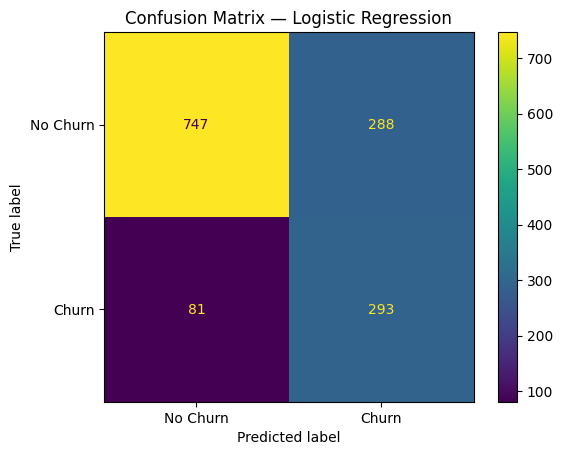

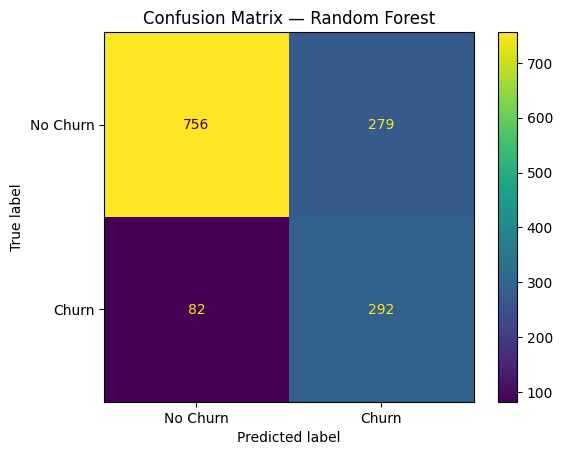

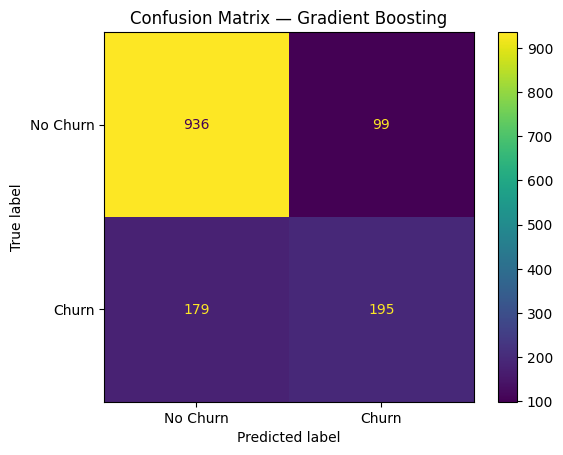

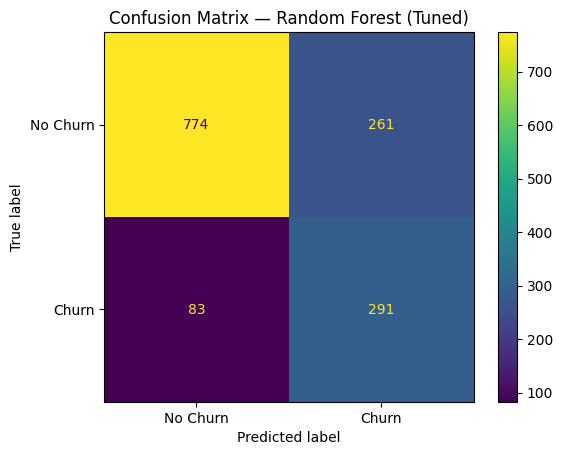

In [ ]:
for name, model in models.items():  # Review the confusion matrix for each candidate model.
    predictions = model.predict(X_test)  # Generate test predictions for the current model.
    ConfusionMatrixDisplay.from_predictions(y_test, predictions, display_labels=["No Churn", "Churn"])  # Display labelled prediction outcomes.
    plt.title(f"Confusion Matrix — {name}")  # Add the current model name to the chart.
    plt.show()  # Display the confusion matrix.

### What was done and why

The confusion matrices make it easier to see where each model succeeds and fails.

The most important cells are:

- **Actual Churn → Predicted No Churn:** missed churners.
- **Actual No Churn → Predicted Churn:** unnecessary churn flags.

This evidence is needed for the later business-error analysis.

In [ ]:
error_df["Missed Churn Rate"] = error_df["False Negatives"] / (error_df["False Negatives"] + error_df["True Positives"])  # Calculate the proportion of actual churners that were missed.
error_df["False Alarm Rate"] = error_df["False Positives"] / (error_df["False Positives"] + error_df["True Negatives"])  # Calculate the proportion of non-churners incorrectly flagged.
display(error_df[["Model Name", "Missed Churn Rate", "False Alarm Rate"]].sort_values("Missed Churn Rate"))  # Compare the two main business error rates.

,Model Name,Missed Churn Rate,False Alarm Rate
0,Logistic Regression,0.216578,0.278261
1,Random Forest,0.219251,0.269565
3,Random Forest (Tuned),0.221925,0.252174
2,Gradient Boosting,0.478610,0.095652


### What was done and why

Counts alone can be misleading.

**Missed Churn Rate** shows the proportion of actual churners that the model failed to detect. It is the complement of recall.

**False Alarm Rate** shows the proportion of customers who did not churn but were incorrectly flagged.

These measures make the trade-off between aggressive churn detection and unnecessary intervention easier to explain.

## 4. Classification Threshold Analysis

### Why the threshold matters

The model can produce a probability of churn rather than only a Yes/No prediction.

The common default is:

**Probability ≥ 0.50 → Churn**

**Probability < 0.50 → No Churn**

Changing this threshold changes the balance between missed churners and unnecessary churn flags.

A lower threshold generally makes the model more willing to flag customers as potential churners. This can increase recall but also increase false alarms.

A higher threshold generally makes the model more conservative. This can reduce false alarms but may increase missed churners.

Therefore, threshold selection is both a technical and business decision.

In [ ]:
thresholds = [0.30, 0.35, 0.40, 0.50, 0.60, 0.70]  # Define a small range of thresholds for sensitivity analysis.
threshold_results = []  # Create a list for storing threshold results.
for name, model in models.items():  # Analyse threshold behaviour for every candidate model.
    probabilities = model.predict_proba(X_test)[:, 1]  # Obtain each customer's estimated probability of churn.
    for threshold in thresholds:  # Test each selected classification threshold.
        predictions = (probabilities >= threshold).astype(int)  # Convert probabilities into churn/no-churn predictions using the current threshold.
        tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()  # Calculate the confusion-matrix outcomes at the current threshold.
        threshold_results.append({"Model Name": name, "Threshold": threshold, "Precision": precision_score(y_test, predictions, zero_division=0), "Recall": recall_score(y_test, predictions, zero_division=0), "F1 Score": f1_score(y_test, predictions, zero_division=0), "False Positives": fp, "False Negatives": fn})  # Store performance and error counts.
threshold_df = pd.DataFrame(threshold_results)  # Convert the threshold results into a DataFrame.
display(threshold_df)  # Display the threshold sensitivity analysis.

,Model Name,Threshold,Precision,Recall,F1 Score,False Positives,False Negatives
0,Logistic Regression,0.30,0.429455,0.927807,0.587140,461,27
1,Logistic Regression,0.35,0.447090,0.903743,0.598230,418,36
2,Logistic Regression,0.40,0.466859,0.866310,0.606742,370,50
3,Logistic Regression,0.50,0.504303,0.783422,0.613613,288,81
4,Logistic Regression,0.60,0.539877,0.705882,0.611819,225,110
5,Logistic Regression,0.70,0.603217,0.601604,0.602410,148,149
6,Random Forest,0.30,0.420482,0.933155,0.579734,481,25
7,Random Forest,0.35,0.439153,0.887701,0.587611,424,42
8,Random Forest,0.40,0.457797,0.855615,0.596459,379,54
9,Random Forest,0.50,0.511384,0.780749,0.617989,279,82


### What was done and why

This is the central threshold-sensitivity analysis.

For each candidate model, the notebook:

1. obtains predicted churn probabilities;
2. applies each selected threshold;
3. converts probabilities into churn/no-churn predictions;
4. calculates precision, recall and F1;
5. counts false positives and false negatives.

The purpose is to show how changing the operating threshold changes the two business-critical errors.

**Important:** this is sensitivity analysis, not final threshold tuning. Because the supplied pipeline does not provide a separate validation set, the notebook does not claim that one of these test-set thresholds is the final production threshold.

In [ ]:
selected_model_name = comparison.sort_values(["F1 Score", "Recall"], ascending=False).iloc[0]["Model Name"]  # Identify the provisional leading model using the existing F1-first rule.
selected_threshold_results = threshold_df[threshold_df["Model Name"] == selected_model_name]  # Keep threshold results for the provisional leading model.
display(selected_threshold_results)  # Display how the leading model behaves across the tested thresholds.

,Model Name,Threshold,Precision,Recall,F1 Score,False Positives,False Negatives
18,Random Forest (Tuned),0.30,0.432468,0.890374,0.582168,437,41
19,Random Forest (Tuned),0.35,0.458807,0.863636,0.599258,381,51
20,Random Forest (Tuned),0.40,0.487578,0.839572,0.616896,330,60
21,Random Forest (Tuned),0.50,0.527174,0.778075,0.628510,261,83
22,Random Forest (Tuned),0.60,0.572093,0.657754,0.611940,184,128
23,Random Forest (Tuned),0.70,0.657627,0.518717,0.579970,101,180


### What was done and why

The existing evaluation rule uses F1 as the initial comparison priority and recall as the tie-breaker.

This cell therefore focuses threshold analysis on the provisional leading model.

I am using this table to discuss the trade-off between detecting more churners and generating more false alarms.

The final threshold should ideally be selected using validation data or cross-validation before the final holdout evaluation.

## 5. Business Error Analysis

### Missed churners — False Negatives

A false negative occurs when:

**Actual outcome = Churn**

**Model prediction = No Churn**

Business consequence: the retention team may fail to target a customer who is genuinely at risk of leaving. This represents a missed retention opportunity and potentially lost customer revenue.

### Unnecessary churn flags — False Positives

A false positive occurs when:

**Actual outcome = No Churn**

**Model prediction = Churn**

Business consequence: the company may spend retention resources, offers or staff time on customers who were not actually going to churn.

### Threshold trade-off

Lowering the threshold can reduce missed churners but may create more false alarms.

Raising the threshold can reduce false alarms but may allow more churners to go undetected.

The appropriate operating point therefore depends on the business priority.

In [ ]:
business_summary = error_df[["Model Name", "Missed Churn Rate", "False Alarm Rate"]].copy()  # Select the two error rates most relevant to the business decision.
display(business_summary.sort_values("Missed Churn Rate"))  # Present models from lowest to highest missed-churn rate.

,Model Name,Missed Churn Rate,False Alarm Rate
0,Logistic Regression,0.216578,0.278261
1,Random Forest,0.219251,0.269565
3,Random Forest (Tuned),0.221925,0.252174
2,Gradient Boosting,0.478610,0.095652


### What was done and why

This table provides a concise business-facing comparison.

it is used to answer:

> Which model misses fewer customers who actually churn?

and:

> How many non-churners are being unnecessarily flagged?

I will discuss the answers with the Product Manager and Business Analyst before the final operating choice is frozen.

## 5.1 Investigation of Missed Churners and Unnecessary Churn Flags

The confusion matrix tells us how many errors were made, but the project requirement also asks us to investigate the customers represented by those errors.

This section therefore examines the characteristics of the provisional leading model's False Negative and False Positive groups. The analysis uses the prepared features available to the evaluation notebook and does not claim that any feature causes churn.


In [ ]:
# Identify the provisional leading model using the same F1-first and Recall-second rule.
selected_model = models[selected_model_name]  # Retrieve the provisional leading model from the model registry.
selected_predictions = selected_model.predict(X_test)  # Generate the model's predictions on the holdout test data.
error_cases = X_test.copy()  # Copy the test features so error labels can be added without changing the source data.
error_cases["Actual Churn"] = y_test.to_numpy()  # Add the actual churn outcome to each test record.
error_cases["Predicted Churn"] = selected_predictions  # Add the model's predicted churn outcome to each test record.
false_negatives = error_cases[(error_cases["Actual Churn"] == 1) & (error_cases["Predicted Churn"] == 0)]  # Isolate customers the model missed.
false_positives = error_cases[(error_cases["Actual Churn"] == 0) & (error_cases["Predicted Churn"] == 1)]  # Isolate customers incorrectly flagged as churners.
print("Provisional leading model:", selected_model_name)  # Identify which model's errors are being investigated.
print("Missed churners (False Negatives):", len(false_negatives))  # Report the number of actual churners the model missed.
print("Unnecessary churn flags (False Positives):", len(false_positives))  # Report the number of non-churners the model incorrectly flagged.


Provisional leading model: Random Forest (Tuned)
Missed churners (False Negatives): 83
Unnecessary churn flags (False Positives): 261


### What was done and why

The provisional leading model is used because the project first needs to identify the strongest candidate before investigating its specific error patterns.

False Negatives are isolated as actual churners predicted as No Churn. False Positives are isolated as actual non-churners predicted as Churn.

This moves the analysis beyond simply reporting an error rate and gives Julius a concrete population to investigate.


In [ ]:
def error_profile(data, label):  # Define a small helper function to summarise the characteristics of an error group.
    profile = {  # Create the business-relevant summary fields.
        "Error Group": label,  # Record the name of the error group.
        "Count": len(data),  # Count customers in the error group.
        "Average Tenure": data["numerical__tenure"].mean(),  # Calculate average tenure.
        "Average Monthly Charges": data["numerical__MonthlyCharges"].mean(),  # Calculate average monthly charges.
        "Average Total Charges": data["numerical__TotalCharges"].mean(),  # Calculate average cumulative charges.
        "Month-to-month Rate": data["categorical__Contract_Month-to-month"].mean(),  # Calculate the share on month-to-month contracts.
        "Fiber Optic Rate": data["categorical__InternetService_Fiber optic"].mean(),  # Calculate the share using fiber optic internet.
        "Tech Support Yes Rate": data["categorical__TechSupport_Yes"].mean(),  # Calculate the share with tech support.
        "Electronic Check Rate": data["categorical__PaymentMethod_Electronic check"].mean(),  # Calculate the share paying by electronic check.
        "Senior Citizen Rate": data["categorical__SeniorCitizen_1"].mean()  # Calculate the share of senior citizens.
    }  # Complete the error-group summary.
    return profile  # Return the completed profile for the selected error group.
error_profiles = pd.DataFrame([  # Build one comparable profile for each error type.
    error_profile(false_negatives, "False Negatives — Missed Churners"),  # Summarise the customers the model missed.
    error_profile(false_positives, "False Positives — Unnecessary Flags")  # Summarise the customers the model flagged unnecessarily.
])  # Complete the comparison table.
display(error_profiles)  # Display the characteristics of the two error groups.


,Error Group,Count,Average Tenure,Average Monthly Charges,Average Total Charges,Month-to-month Rate,Fiber Optic Rate,Tech Support Yes Rate,Electronic Check Rate,Senior Citizen Rate
0,False Negatives — Missed Churners,83,-0.023179,0.049121,0.171334,0.493976,0.385542,0.397590,0.289157,0.132530
1,False Positives — Unnecessary Flags,261,-0.551260,0.311319,-0.290910,0.973180,0.708812,0.195402,0.528736,0.210728


### What was done and why

The two error groups are summarised using a small set of interpretable customer characteristics already present in the prepared dataset.

The purpose is not to create another EDA section. It is to identify whether the model's mistakes show clear, observable differences that I can communicate to the business team.

The resulting values are descriptive only. They show characteristics of the observed error groups; they do not prove that those characteristics caused the errors or caused churn.


## 6. Evidence-Based Final Model and Threshold Recommendation

The final recommendation should be based on:

1. overall predictive performance;
2. missed-churn rate;
3. false-alarm rate;
4. threshold sensitivity;
5. business priority.

If the business places greater cost on missed churners, a model/threshold combination with stronger recall may be preferred even if it produces more false alarms.

If retention resources are limited and false alarms are especially costly, a more conservative threshold may be appropriate.

### Important

The current notebook performs threshold **sensitivity analysis**. It does not claim that the final threshold has been tuned because the supplied pipeline does not contain a separate validation set.

The final threshold should therefore be selected using an appropriate validation strategy before the final model is locked.
After execution, the model-comparison table, error analysis and threshold table provide the evidence used to support Julius's recommendation. The final production threshold remains subject to validation and business-cost agreement.


In [2]:
recommended_row = comparison.sort_values(["F1 Score", "Recall"], ascending=False).iloc[0]  # Select the provisional model using the existing F1-first rule.
print("Provisional model recommendation:", recommended_row["Model Name"])  # Report the provisional model choice.
print("F1 Score:", recommended_row["F1 Score"])  # Report its F1 score.
print("Recall:", recommended_row["Recall"])  # Report its recall.
print("Precision:", recommended_row["Precision"])  # Report its precision.
print("ROC-AUC:", recommended_row["ROC-AUC"])  # Report its ROC-AUC.

NameError: name 'comparison' is not defined

### What was done and why

This produces a transparent provisional model recommendation using the same criteria established earlier.

It is not an automatic production decision.

we must combine the model-performance evidence with the threshold analysis and the business cost of false negatives versus false positives before the final model and threshold are frozen.

## 7. Model Limitations


- Results are based on the supplied dataset and may not represent every telecom customer population.
- Holdout-test performance does not guarantee identical performance after deployment.
- Model performance does not establish causation between customer characteristics and churn.
- Every candidate can still produce false positives and false negatives.
- Threshold choice changes the balance between missed churners and unnecessary churn flags.
- The current threshold analysis should not be treated as final threshold tuning because the supplied pipeline does not contain a separate validation set.
- The evaluation inherits limitations present in upstream data preparation and the dataset.
- Performance should be monitored if the model is later used with new customer data.

## 8. Handoff to the Team

### Model Evaluation Lead — Julius Azinkpali

The required handoff is:

1. **Model comparison** — performance of all candidate models.
2. **Business error analysis** — missed churners and unnecessary churn flags.
3. **Threshold sensitivity analysis** — how different thresholds change precision, recall, false positives and false negatives.
4. **Business interpretation** — consequences of the competing errors.
5. **Evidence-based recommendation** — recommended model and the evidence supporting it.
6. **Limitations** — assumptions and limitations that must accompany the recommendation.

### Stage Gate

The evaluation stage is complete when the team can answer:

> **Which model are we recommending, what threshold should be considered for its operating point, what evidence supports the choice, what errors does it make, what do those errors mean to the business, and what limitations must be disclosed?**

## 9. Final Evaluation Checklist

- [ ] Candidate models received from Model Development.
- [ ] Experiment log reviewed.
- [ ] Accuracy compared.
- [ ] Precision compared.
- [ ] Recall compared.
- [ ] F1 compared.
- [ ] ROC-AUC compared.
- [ ] Confusion matrices reviewed.
- [ ] Missed churners investigated.
- [ ] Unnecessary churn flags investigated.
- [ ] Threshold sensitivity tested.
- [ ] Precision/recall trade-off reviewed across thresholds.
- [ ] False-positive/false-negative trade-off reviewed across thresholds.
- [ ] Business consequences documented.
- [ ] Model and threshold recommendation discussed with the team.
- [ ] Final recommendation agreed.
- [ ] Model limitations documented.
- [ ] Evaluation findings handed over for final model selection and prototype integration.

**Lead:** Julius Azinkpali